In [216]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [217]:
# =====================================================
# Load Dataset & Basic Preprocessing
# =====================================================

df = pd.read_csv('../Data/features-column.csv')
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)   
df.drop("Close", axis=1, inplace=True)

In [218]:
# 80% train, 20% test
split = int(len(df) * 0.8)

train = df.iloc[:split]
test  = df.iloc[split:]

print(f"Train: {train.index[0].date()} to {train.index[-1].date()}")
print(f"Test:  {test.index[0].date()} to {test.index[-1].date()}")
print(f"Train rows: {len(train)}, Test rows: {len(test)}")

Train: 2010-02-18 to 2022-01-06
Test:  2022-01-07 to 2024-12-31
Train rows: 3053, Test rows: 764


In [219]:
X_train = train.drop(columns=['Target'])
y_train = train['Target']

X_test = test.drop(columns=['Target'])
y_test = test['Target']

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")

X_train shape: (3053, 13)
X_test shape:  (764, 13)


In [220]:
print(f"\nTarget Distribution (Test):")
print(y_test.value_counts())
print(f"UP %   : {y_test.mean()*100:.1f}%")
print(f"DOWN % : {(1-y_test.mean())*100:.1f}%")


Target Distribution (Test):
Target
1    393
0    371
Name: count, dtype: int64
UP %   : 51.4%
DOWN % : 48.6%


In [221]:
from sklearn.ensemble import RandomForestClassifier

# ===== MODEL =====
model = RandomForestClassifier(
    n_estimators=250,
    max_depth=10,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [222]:
from sklearn.metrics import accuracy_score, classification_report,confusion_matrix

acc = accuracy_score(y_test, y_pred)
print(f"ACCURACY : {acc*100:.2f}%")

print(f"\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['DOWN', 'UP']))

ACCURACY : 50.92%

Classification Report:
              precision    recall  f1-score   support

        DOWN       0.50      0.60      0.54       371
          UP       0.53      0.42      0.47       393

    accuracy                           0.51       764
   macro avg       0.51      0.51      0.51       764
weighted avg       0.51      0.51      0.51       764



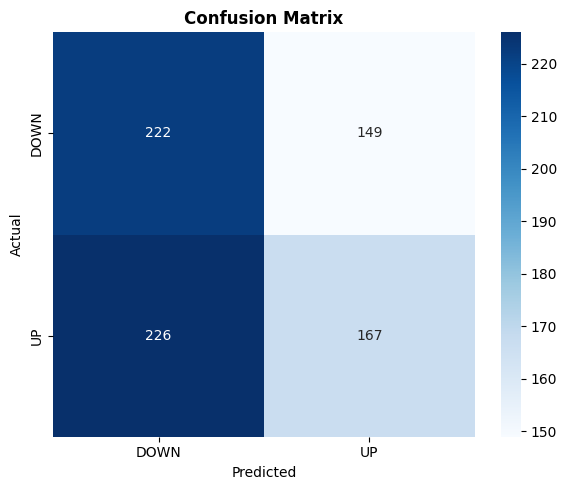

In [223]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['DOWN', 'UP'],
            yticklabels=['DOWN', 'UP'])
plt.title('Confusion Matrix', fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

In [224]:
import joblib

# Model saved
joblib.dump(model, 'randomforestmodel.pkl')
print("✅ Model saved successfully!")

✅ Model saved successfully!


In [225]:
feature_columns = list(X_train.columns)

joblib.dump(feature_columns, 'feature_columns.pkl')
print("Feature columns saved!")
print(feature_columns)  
print(f"\nTotal features: {len(feature_columns)}")

Feature columns saved!
['RSI', 'MACD', 'MACD_Signal', 'MACD_Hist', 'BB_Pct', 'BB_Width', 'rolling_7_std', 'Daily_Range', 'Daily_Return', 'Volume', 'day_of_week', 'month', 'quarter']

Total features: 13
